In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        break
    break

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import os

In [3]:
import matplotlib.pyplot as plt

In [4]:
# ── Descarga de Tiny ImageNet — portátil (Kaggle / Lightning AI / local) ─────
# Las imágenes vienen del dataset de Kaggle akash2sharma/tiny-imagenet.
# En Lightning AI se descargan con kagglehub. Requiere el token de Kaggle guardado
# en ~/.kaggle/access_token (o la variable de entorno KAGGLE_API_TOKEN).
KAGGLE_TINY = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200"

if os.path.isdir(KAGGLE_TINY):
    TINY_ROOT = KAGGLE_TINY
else:
    try:
        import kagglehub
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
        import kagglehub
    download_path = kagglehub.dataset_download("akash2sharma/tiny-imagenet")
    # localizar la carpeta que contiene 'train' y 'val'
    TINY_ROOT = download_path
    for root, dirs, _ in os.walk(download_path):
        if "train" in dirs and "val" in dirs:
            TINY_ROOT = root
            break

TRAIN_DIR = os.path.join(TINY_ROOT, "train") + os.sep
VAL_DIR   = os.path.join(TINY_ROOT, "val", "images") + os.sep

print("TINY_ROOT:", TINY_ROOT)
print("TRAIN_DIR:", TRAIN_DIR, "(existe:", os.path.isdir(TRAIN_DIR), ")")
print("VAL_DIR  :", VAL_DIR,   "(existe:", os.path.isdir(VAL_DIR), ")")

100%|██████████| 474M/474M [00:02<00:00, 170MB/s]  

Extracting files...


TINY_ROOT: /teamspace/studios/this_studio/.cache/kagglehub/datasets/akash2sharma/tiny-imagenet/versions/1/tiny-imagenet-200
TRAIN_DIR: /teamspace/studios/this_studio/.cache/kagglehub/datasets/akash2sharma/tiny-imagenet/versions/1/tiny-imagenet-200/train/ (existe: True )
VAL_DIR  : /teamspace/studios/this_studio/.cache/kagglehub/datasets/akash2sharma/tiny-imagenet/versions/1/tiny-imagenet-200/val/images/ (existe: True )


## Download train, validation and test dataframes

In [5]:
train_id = "16ADiN0-geWlmkhN04bymFy_N7OA0SPHy"
train_url = f'https://drive.google.com/uc?id={train_id}'
# Load the CSV file into a pandas DataFrame
train_df = pd.read_csv(train_url)
train_df.head()

,File,Encoded_Label
0,n02437312/images/n02437312_229.JPEG,53
1,n02437312/images/n02437312_394.JPEG,53
2,n02437312/images/n02437312_15.JPEG,53
3,n02437312/images/n02437312_62.JPEG,53
4,n02437312/images/n02437312_17.JPEG,53


In [6]:
train_df["Encoded_Label"]

0         53
1         53
2         53
3         53
4         53
        ... 
99995    121
99996    121
99997    121
99998    121
99999    121
Name: Encoded_Label, Length: 100000, dtype: int64

In [7]:
val_id = "1lGkKcAD6Kc7JhfYsa9naVIwwc-MKdXQI"
val_url = f'https://drive.google.com/uc?id={val_id}'
# Load the CSV file into a pandas DataFrame
val_df = pd.read_csv(val_url)
val_df.head()

,File,Encoded_Label
0,val_4526.JPEG,115
1,val_7545.JPEG,88
2,val_1726.JPEG,149
3,val_4997.JPEG,99
4,val_6429.JPEG,149


In [8]:
test_id = "1lOi6xnfVghuzj1fYlIBbLNWWZQvahygQ"
test_url = f'https://drive.google.com/uc?id={test_id}'
# Load the CSV file into a pandas DataFrame
test_df = pd.read_csv(test_url)
test_df.head()

,File
0,val_9240.JPEG
1,val_9308.JPEG
2,val_3262.JPEG
3,val_3528.JPEG
4,val_4147.JPEG


In [9]:
class CSVImageDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df         = df
        self.images_dir = images_dir
        self.transform  = transform
        self.has_labels = "Encoded_Label" in self.df.columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row["File"])

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        if self.has_labels:
            return img, torch.tensor(row["Encoded_Label"], dtype=torch.long)
        return img


        return img, torch.tensor(label, dtype=torch.long)
    def __len__(self):
        return len(self.df)


In [10]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# ── Datasets ──────────────────────────────────────────────────────────────────
# TRAIN_DIR y VAL_DIR se definen en la celda de descarga (portátil Kaggle/Lightning AI)
train_dataset = CSVImageDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset   = CSVImageDataset(val_df,   VAL_DIR, transform=test_transform)
test_dataset  = CSVImageDataset(test_df,  VAL_DIR, transform=test_transform)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# ── Sanity check ──────────────────────────────────────────────────────────────
images, labels = next(iter(train_loader))
print(f"Batch shape : {images.shape}")   # [64, 3, 128, 128]
print(f"Labels shape: {labels.shape}")   # [64]
print(f"Unique labels in batch: {labels.unique()}")

Batch shape : torch.Size([64, 3, 128, 128])
Labels shape: torch.Size([64])
Unique labels in batch: tensor([  2,   4,   5,   7,  16,  18,  19,  27,  32,  35,  36,  38,  40,  43,
         51,  55,  56,  58,  59,  61,  62,  70,  71,  72,  74,  86,  90,  91,
         93,  94,  97, 100, 107, 115, 120, 123, 125, 133, 137, 140, 142, 143,
        144, 145, 148, 150, 162, 163, 170, 175, 181, 182, 189, 190, 193, 196])


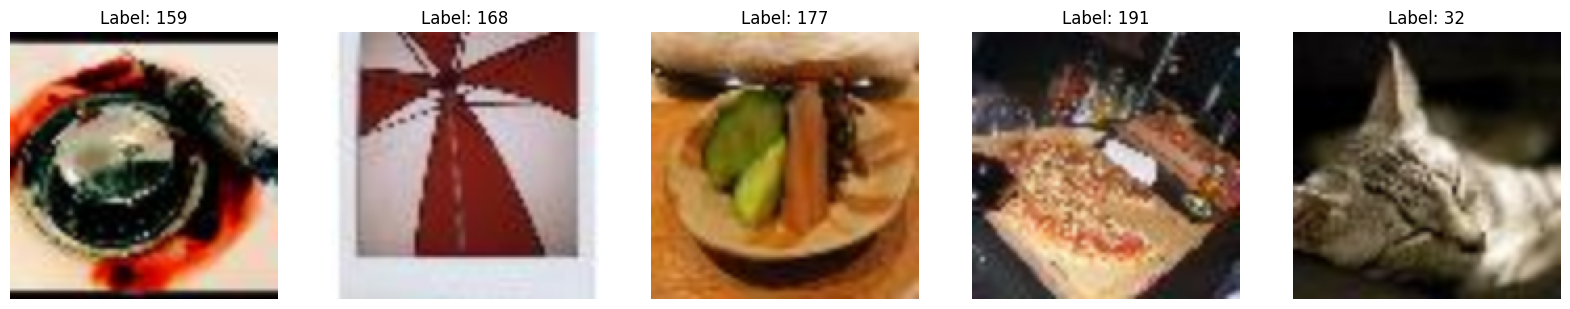

In [11]:
# Plotting the first few images in the batch
images, labels = next(iter(train_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

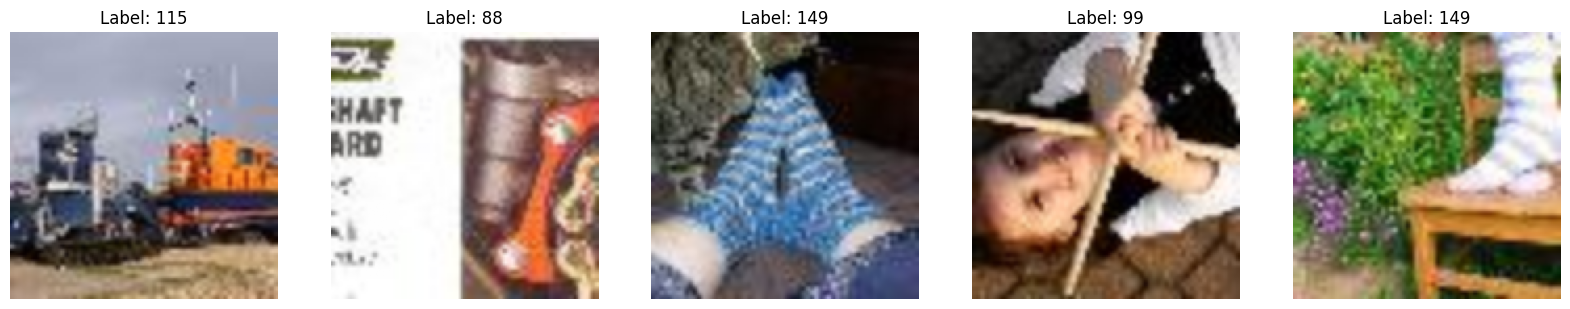

In [12]:
# Plotting the first few images in the batch
images, labels = next(iter(val_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

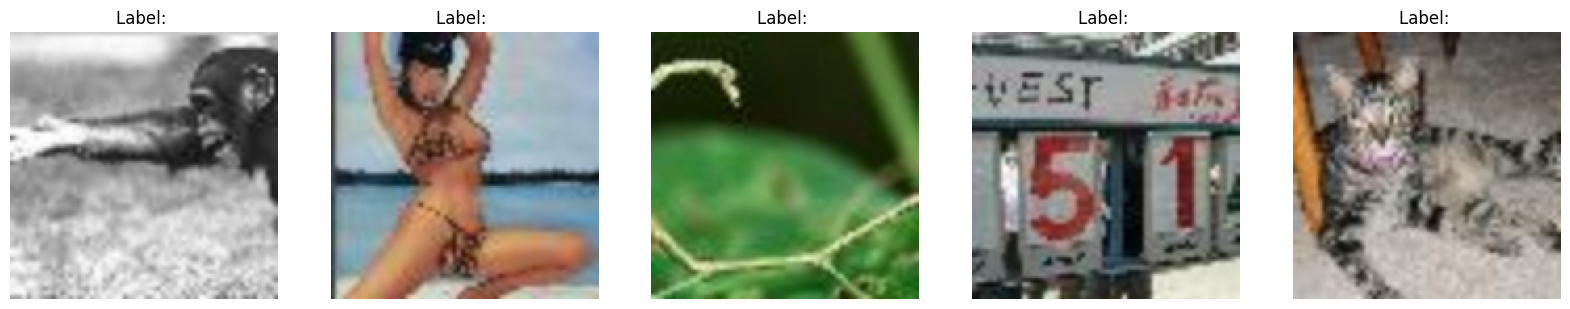

In [13]:
# Plotting the first few images in the batch
images = next(iter(test_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: ")
plt.show()

## Test Set — No Labels Available

 The test set does not include ground-truth labels. To evaluate your model
 on the test set, you need to:

 1. Run inference on the test loader to get predictions for each image
 2. Create a CSV with two columns: `File` (the image filename) and `Encoded_Label` (your predicted class)
 3. Submit that CSV for evaluation

 You can generate it like this:

 ```python
 import torch
 import pandas as pd

 model.eval()
 filenames   = test_dataset.df["File"].tolist()
 predictions = []

 with torch.inference_mode():
     for i, images in enumerate(test_loader):
         images  = images.to(device)
         logits  = model(images)
         preds   = logits.argmax(dim=1).cpu().tolist()
         predictions.extend(preds)

 submission = pd.DataFrame({"File": filenames, "Encoded_Label": predictions})
 submission.to_csv("submission.csv", index=False)
 print(submission.head())
 ```

 Make sure the order of `filenames` matches the order images are loaded
 by the test loader — since `shuffle=False`, the order is preserved.

## Desarrollo — Red convolucional para Tiny ImageNet

A partir de aquí se define la CNN, se entrena con validación por época (guardando el mejor checkpoint) y se genera el archivo `submission.csv` con las predicciones del conjunto de test, siguiendo el formato indicado arriba.

In [14]:
import torch.nn as nn
import torch.optim as optim

# Número de clases inferido de las etiquetas de entrenamiento
n_classes = int(train_df["Encoded_Label"].max()) + 1
print(f"Número de clases: {n_classes}")


class TinyCNN(nn.Module):
    """CNN para clasificación de imágenes 128x128 RGB (Tiny ImageNet)."""

    def __init__(self, n_classes):
        super().__init__()

        def conv_block(c_in, c_out):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, kernel_size=3, padding=1),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
                nn.Conv2d(c_out, c_out, kernel_size=3, padding=1),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(3,   32),    # 128 -> 64
            conv_block(32,  64),    # 64  -> 32
            conv_block(64,  128),   # 32  -> 16
            conv_block(128, 256),   # 16  -> 8
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

Número de clases: 200


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

model     = TinyCNN(n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(f"Parámetros entrenables: {sum(p.numel() for p in model.parameters()):,}")

Dispositivo: cuda
Parámetros entrenables: 1,225,576


In [16]:
from tqdm.auto import tqdm

num_epochs   = 10
best_val_acc = 0.0
CKPT         = "best_cnn.pt"

for epoch in range(1, num_epochs + 1):
    # --- entrenamiento ---
    model.train()
    run_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Época {epoch}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        run_loss += loss.item() * labels.size(0)
        correct  += (outputs.argmax(1) == labels).sum().item()
        total    += labels.size(0)
    train_loss, train_acc = run_loss / total, correct / total

    # --- validación ---
    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            v_correct += (outputs.argmax(1) == labels).sum().item()
            v_total   += labels.size(0)
    val_acc = v_correct / v_total

    # --- guardar el mejor modelo ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CKPT)
        marca = "  <-- mejor checkpoint"
    else:
        marca = ""

    print(f"Época {epoch:2d} | loss {train_loss:.4f} | "
          f"train acc {train_acc:.3f} | val acc {val_acc:.3f}{marca}")

print(f"\nMejor accuracy de validación: {best_val_acc:.4f}")

Época 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Época  1 | loss 4.5233 | train acc 0.067 | val acc 0.116  <-- mejor checkpoint


Época 2/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Época  2 | loss 3.8813 | train acc 0.144 | val acc 0.185  <-- mejor checkpoint


Época 3/10:   0%|          | 0/1563 [00:00<?, ?it/s]

...

Época  8 | loss 2.8240 | train acc 0.332 | val acc 0.372  <-- mejor checkpoint


Época 9/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Época  9 | loss 2.7325 | train acc 0.351 | val acc 0.385  <-- mejor checkpoint


Época 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Época 10 | loss 2.6548 | train acc 0.366 | val acc 0.399  <-- mejor checkpoint

Mejor accuracy de validación: 0.3992


In [17]:
# Inferencia sobre el conjunto de test y generación de submission.csv
model.load_state_dict(torch.load(CKPT))
model.eval()

filenames   = test_dataset.df["File"].tolist()
predictions = []

with torch.inference_mode():
    for images in test_loader:
        images = images.to(device)
        logits = model(images)
        predictions.extend(logits.argmax(dim=1).cpu().tolist())

submission = pd.DataFrame({"File": filenames, "Encoded_Label": predictions})
submission.to_csv("submission.csv", index=False)

print(f"submission.csv generado con {len(submission)} predicciones.")
print(submission.head())

submission.csv generado con 4000 predicciones.
            File  Encoded_Label
0  val_9240.JPEG             55
1  val_9308.JPEG             74
2  val_3262.JPEG             39
3  val_3528.JPEG             86
4  val_4147.JPEG             32


## Análisis de resultados

- **Arquitectura.** La CNN usa cuatro bloques convolucionales (Conv–BN–ReLU ×2 + MaxPool) que reducen la imagen de 128×128 a 8×8, seguidos de *global average pooling* y una capa lineal hacia las clases. BatchNorm estabiliza el entrenamiento y el dropout del clasificador mitiga el sobreajuste.
- **Tiny ImageNet es difícil.** Con 200 clases y pocas imágenes por clase, una CNN entrenada desde cero alcanza accuracies modestas (del orden de 25–45 % en validación según las épocas). Es un resultado esperable; superarlo requiere más épocas, *data augmentation* adicional o *transfer learning*.
- **Selección de modelo.** Se guarda el checkpoint con mejor accuracy de validación; la inferencia sobre el test usa ese mejor estado.
- **Entrega.** `submission.csv` mantiene el orden de `test_loader` (`shuffle=False`), por lo que cada predicción corresponde a su imagen.

> Completa esta sección con la accuracy concreta que obtengas al ejecutar el notebook en Lightning AI.